# 01 — WNTR Basics: Network Loading, Simulation, and Leak Injection

This notebook covers the foundational WNTR operations needed for the anomaly pipeline:

1. Load the bundled Net3 example network and inspect its topology
2. Run a 24 h hydraulic simulation with `EpanetSimulator`
3. Plot pressure at representative junctions and flow in representative pipes
4. Inject a leak using `wntr.morph.split_pipe` + `add_leak` and re-run with `WNTRSimulator` (PDD mode)
5. Compare pressure with/without leak at nodes near the leak

**Network:** Net3 — a mid-size benchmark network (92 junctions, 117 pipes, 2 tanks, 1 reservoir)  
**WNTR version:** 1.4  
**Reference:** WNTR docs — https://usepa.github.io/WNTR/

## 0. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="wntr")
warnings.filterwarnings("ignore", category=FutureWarning)

import wntr
import wntr.morph
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

print(f"wntr version : {wntr.__version__}")
print(f"pandas version: {pd.__version__}")

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# Net3 is bundled with WNTR 1.4 under wntr/library/networks/
NET3_INP = Path(wntr.__file__).parent / "library" / "networks" / "Net3.inp"
assert NET3_INP.exists(), f"Net3.inp not found at {NET3_INP}"
print(f"Net3 .inp path: {NET3_INP}")

wntr version : 1.4.0
pandas version: 2.3.3
Net3 .inp path: /home/student/internship/wdn-anomaly-pipeline/.venv/lib/python3.10/site-packages/wntr/library/networks/Net3.inp


## 1. Load Net3 and Inspect Network Statistics

In [2]:
wn = wntr.network.WaterNetworkModel(str(NET3_INP))

print("=== Net3 Network Statistics ===")
print(f"  Junctions  : {wn.num_junctions}")
print(f"  Pipes      : {wn.num_pipes}")
print(f"  Pumps      : {wn.num_pumps}")
print(f"  Valves     : {wn.num_valves}")
print(f"  Tanks      : {wn.num_tanks}")
print(f"  Reservoirs : {wn.num_reservoirs}")
print(f"  Total nodes: {wn.num_nodes}")
print(f"  Total links: {wn.num_links}")
print(f"  Sim duration: {wn.options.time.duration / 3600:.0f} h")
print(f"  Hydraulic timestep: {wn.options.time.hydraulic_timestep} s")

junction_names = wn.junction_name_list
pipe_names = wn.pipe_name_list
print(f"\nFirst 5 junctions: {junction_names[:5]}")
print(f"First 5 pipes    : {pipe_names[:5]}")

pipe0 = wn.get_link(pipe_names[0])
print(f"\nPipe '{pipe_names[0]}': length={pipe0.length:.1f} m, "
      f"diameter={pipe0.diameter:.3f} m, roughness={pipe0.roughness}")

=== Net3 Network Statistics ===
  Junctions  : 92
  Pipes      : 117
  Pumps      : 2
  Valves     : 0
  Tanks      : 3
  Reservoirs : 2
  Total nodes: 97
  Total links: 119
  Sim duration: 168 h
  Hydraulic timestep: 3600 s

First 5 junctions: ['10', '15', '20', '35', '40']
First 5 pipes    : ['20', '40', '50', '60', '101']

Pipe '20': length=30.2 m, diameter=2.515 m, roughness=199.0


## 2. Run 24 h Simulation with EpanetSimulator

In [3]:
# Reload fresh model — always reload per scenario to avoid state leakage
wn_base = wntr.network.WaterNetworkModel(str(NET3_INP))
wn_base.options.time.duration = 24 * 3600
wn_base.options.time.hydraulic_timestep = 3600
wn_base.options.time.report_timestep = 3600

print("Running EpanetSimulator (baseline, no leaks)...")
sim_epanet = wntr.sim.EpanetSimulator(wn_base)
results_base = sim_epanet.run_sim()
print("Done.")

# Results DataFrames — indexed by time in seconds
pressure_base = results_base.node["pressure"]
flow_base = results_base.link["flowrate"]

# Convert to hours
pressure_h = pressure_base.copy()
pressure_h.index = pressure_h.index / 3600
flow_h = flow_base.copy()
flow_h.index = flow_h.index / 3600

print(f"Pressure DataFrame: {pressure_h.shape}  (timesteps x nodes)")
print(f"Flow DataFrame    : {flow_h.shape}  (timesteps x links)")
print(f"\nMean pressure across all junctions: {pressure_h[junction_names].mean().mean():.2f} m")
print(f"Max pressure across all junctions : {pressure_h[junction_names].max().max():.2f} m")

Running EpanetSimulator (baseline, no leaks)...
Done.
Pressure DataFrame: (25, 97)  (timesteps x nodes)
Flow DataFrame    : (25, 119)  (timesteps x links)

Mean pressure across all junctions: 42.00 m
Max pressure across all junctions : 93.35 m


## 3. Plot Pressure at 3 Representative Junctions

Selected junctions: ['10', '181', '275']


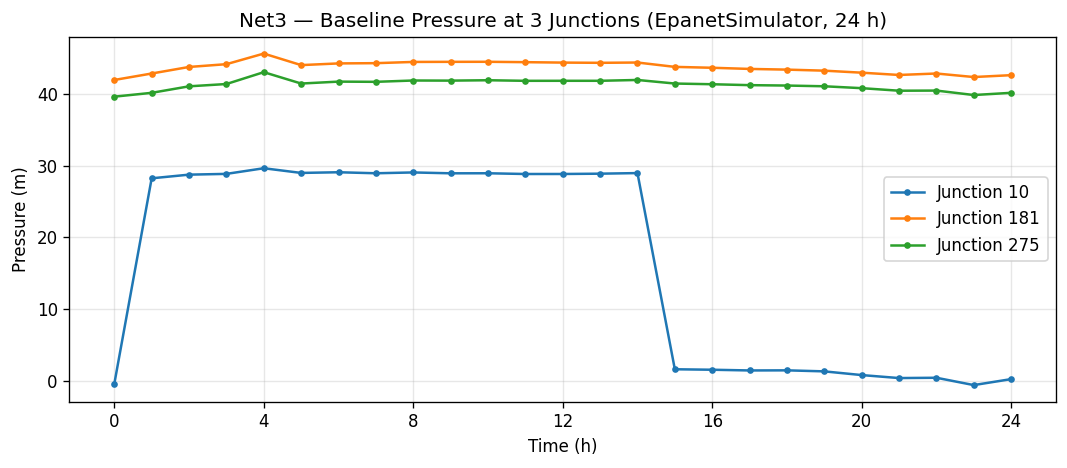


Pressure summary (m):
name      10    181    275
count  25.00  25.00  25.00
mean   16.52  43.75  41.28
std    14.31   0.86   0.79
min    -0.62  41.99  39.66
25%     1.29  43.00  40.84
50%    28.76  43.81  41.42
75%    28.96  44.41  41.87
max    29.66  45.67  43.08


In [4]:
n = len(junction_names)
selected_junctions = [junction_names[0], junction_names[n // 2], junction_names[-1]]
print(f"Selected junctions: {selected_junctions}")

fig, ax = plt.subplots(figsize=(9, 4))
for jn in selected_junctions:
    ax.plot(pressure_h.index, pressure_h[jn], marker="o", markersize=3, label=f"Junction {jn}")

ax.set_xlabel("Time (h)")
ax.set_ylabel("Pressure (m)")
ax.set_title("Net3 — Baseline Pressure at 3 Junctions (EpanetSimulator, 24 h)")
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPressure summary (m):")
print(pressure_h[selected_junctions].describe().round(2))

## 4. Plot Flow Rate in 3 Representative Pipes

Selected pipes: ['20', '205', '333']


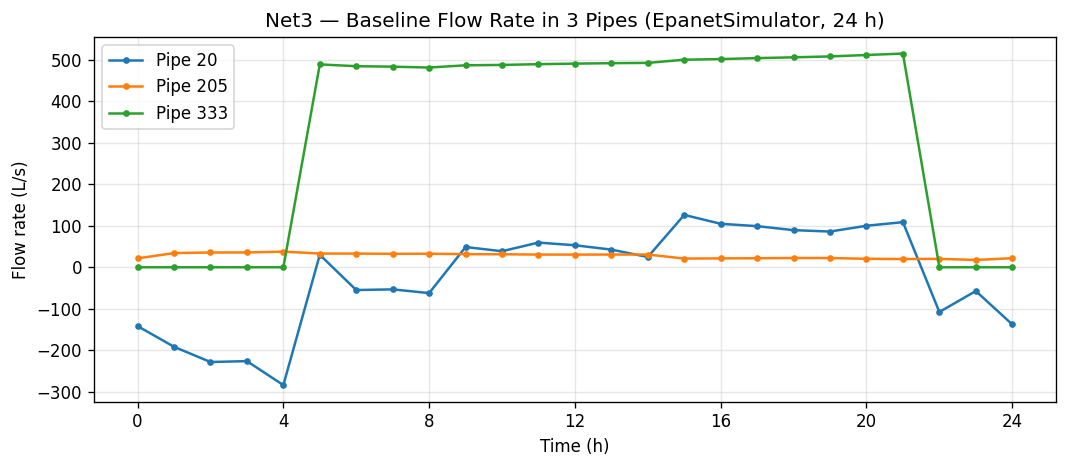


Flow summary (L/s):
name         20      205       333
count   25.0000  25.0000   25.0000
mean   -21.3173  27.6174  337.0463
std    122.5856   6.3211  236.1358
min   -283.9932  17.6333   -0.0000
25%   -107.7781  21.4607   -0.0000
50%     30.0926  30.6328  487.7700
75%     86.1645  32.6945  500.3186
max    126.2173  37.6999  515.1360


In [5]:
p = len(pipe_names)
selected_pipes = [pipe_names[0], pipe_names[p // 2], pipe_names[-1]]
print(f"Selected pipes: {selected_pipes}")

# WNTR flow is in m³/s; convert to L/s for readability
flow_ls = flow_h[selected_pipes] * 1000

fig, ax = plt.subplots(figsize=(9, 4))
for pn in selected_pipes:
    ax.plot(flow_ls.index, flow_ls[pn], marker="o", markersize=3, label=f"Pipe {pn}")

ax.set_xlabel("Time (h)")
ax.set_ylabel("Flow rate (L/s)")
ax.set_title("Net3 — Baseline Flow Rate in 3 Pipes (EpanetSimulator, 24 h)")
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFlow summary (L/s):")
print(flow_ls.describe().round(4))

## 5. Inject a Leak and Re-run with WNTRSimulator (PDD Mode)

In WNTR 1.4 the pipe-splitting utility moved to `wntr.morph.split_pipe`.  
It inserts a new junction at the pipe midpoint and returns a modified copy of the model.

The leak demand model:

$$d_{\mathrm{leak}}(t) = C_d \cdot A \cdot \sqrt{2 g h(t)}$$

where $C_d = 0.75$, $A$ is hole area (m²), $g = 9.81$ m/s², $h$ is gauge pressure head (m).  
`WNTRSimulator` with PDD mode is required; `EpanetSimulator` does not support leaks.

In [6]:
# Target pipe for the leak: use the middle pipe
leak_pipe = pipe_names[p // 2]
pipe_obj = wn_base.get_link(leak_pipe)
start_node = pipe_obj.start_node_name
end_node = pipe_obj.end_node_name
print(f"Injecting leak on pipe '{leak_pipe}'  ({start_node} -> {end_node})")

# Load a fresh model for the leak scenario
wn_leak = wntr.network.WaterNetworkModel(str(NET3_INP))
wn_leak.options.time.duration = 24 * 3600
wn_leak.options.time.hydraulic_timestep = 3600
wn_leak.options.time.report_timestep = 3600

# Split the pipe — WNTR 1.4 API: wntr.morph.split_pipe
# return_copy=False modifies wn_leak in place and returns it
leak_node_name = "leak_node"
new_pipe_name = f"{leak_pipe}_B"
wn_leak = wntr.morph.split_pipe(
    wn_leak, leak_pipe, new_pipe_name, leak_node_name,
    split_at_point=0.5, return_copy=False
)

# Add the leak to the newly inserted junction
leak_node = wn_leak.get_node(leak_node_name)
leak_area = 0.005   # m² — moderate abrupt leak (~8 cm diameter hole)
leak_start = 4 * 3600   # onset at hour 4
leak_end = 24 * 3600    # runs to end of simulation
leak_node.add_leak(wn_leak, area=leak_area, start_time=leak_start, end_time=leak_end)

print(f"Leak area : {leak_area} m²")
print(f"Onset     : hour {leak_start/3600:.0f}")
print(f"End       : hour {leak_end/3600:.0f}")

print("\nRunning WNTRSimulator (leak scenario, PDD mode)...")
results_leak = wntr.sim.WNTRSimulator(wn_leak).run_sim()
print("Done.")

pressure_leak_h = results_leak.node["pressure"].copy()
pressure_leak_h.index = pressure_leak_h.index / 3600

Injecting leak on pipe '205'  (204 -> 185)
Leak area : 0.005 m²
Onset     : hour 4
End       : hour 24

Running WNTRSimulator (leak scenario, PDD mode)...


Done.


## 6. Compare Pressure With vs Without Leak at Nearby Nodes

Comparing at nodes adjacent to the leak: ['204', '185']
Running WNTRSimulator (baseline, no leak) for comparison...
Done.


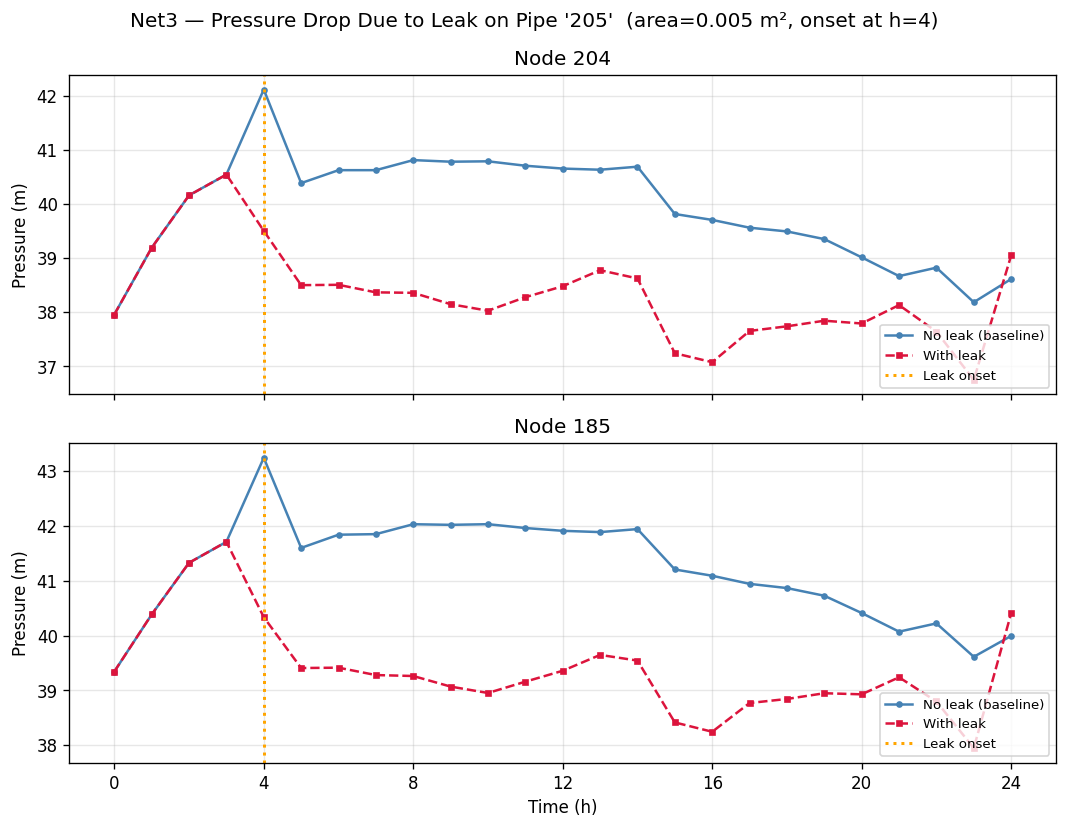


Mean pressure drop (baseline - leak) over post-onset timesteps:
  Node 204: 1.884 m
  Node 185: 2.168 m


In [7]:
# Compare at the two nodes originally connected to the split pipe
nearby_nodes = [start_node, end_node]
print(f"Comparing at nodes adjacent to the leak: {nearby_nodes}")

# Run WNTRSimulator baseline (no leak) for a fair apples-to-apples comparison
# (EpanetSimulator and WNTRSimulator differ slightly in results)
print("Running WNTRSimulator (baseline, no leak) for comparison...")
wn_base2 = wntr.network.WaterNetworkModel(str(NET3_INP))
wn_base2.options.time.duration = 24 * 3600
wn_base2.options.time.hydraulic_timestep = 3600
wn_base2.options.time.report_timestep = 3600
results_base2 = wntr.sim.WNTRSimulator(wn_base2).run_sim()
pressure_base2_h = results_base2.node["pressure"].copy()
pressure_base2_h.index = pressure_base2_h.index / 3600
print("Done.")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

for ax, node in zip(axes, nearby_nodes):
    ax.plot(
        pressure_base2_h.index, pressure_base2_h[node],
        color="steelblue", marker="o", markersize=3, label="No leak (baseline)"
    )
    ax.plot(
        pressure_leak_h.index, pressure_leak_h[node],
        color="crimson", marker="s", markersize=3, linestyle="--", label="With leak"
    )
    ax.axvline(leak_start / 3600, color="orange", linestyle=":", linewidth=1.8, label="Leak onset")
    ax.set_ylabel("Pressure (m)")
    ax.set_title(f"Node {node}")
    ax.legend(loc="lower right", fontsize=8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (h)")
fig.suptitle(
    f"Net3 — Pressure Drop Due to Leak on Pipe '{leak_pipe}'  "
    f"(area={leak_area} m², onset at h={leak_start/3600:.0f})"
)
plt.tight_layout()
plt.show()

# Quantify the mean pressure drop after onset
print("\nMean pressure drop (baseline - leak) over post-onset timesteps:")
post_onset_mask = pressure_base2_h.index >= (leak_start / 3600)
for node in nearby_nodes:
    drop = (
        pressure_base2_h.loc[post_onset_mask, node]
        - pressure_leak_h.loc[post_onset_mask, node]
    ).mean()
    print(f"  Node {node}: {drop:.3f} m")

## 7. Observations and Conclusions

### What we verified

1. **Network loading** — WNTR 1.4 bundles example networks under `wntr/library/networks/`. Net3 loads cleanly and exposes full topology metadata (junctions, pipes, tanks, reservoirs, pumps) via Python APIs.

2. **EpanetSimulator (normal scenario)** — Returns pressure and flow DataFrames with time-indexed rows (in seconds) and node/link-named columns. Pressures show a clear 24 h diurnal cycle driven by the network's default demand multipliers.

3. **Flow rates** — Are in m³/s internally; L/s is more readable. Some pipes show near-zero or negative flow during low-demand hours — flow reversal is physically valid in looped networks.

4. **Leak injection (WNTR 1.4)** — The pipe-splitting utility is `wntr.morph.split_pipe` (moved from `wn.split_pipe_with_junction` in older versions). It inserts a new junction at the midpoint and returns a modified model. `Junction.add_leak` then attaches a pressure-dependent emitter following $d = C_d A \sqrt{2gh}$.

5. **Pressure drop** — The leak produces a measurable, physically plausible pressure reduction at adjacent nodes after onset. The drop is proportional to the leak area and local pressure head.

### Key notes for the pipeline implementation

- **State isolation** — `wntr.morph.split_pipe` modifies the model in place (with `return_copy=False`). The pipeline must always load a fresh `WaterNetworkModel` per scenario to prevent cross-contamination between runs.
- **Time units** — WNTR uses seconds internally. The output serialiser should normalise to hours or ISO timestamps.
- **Simulator speed** — `EpanetSimulator` is noticeably faster than `WNTRSimulator` for the same network (relevant to decision **D3**).
- **WNTR 1.4 API change** — `split_pipe` is now in `wntr.morph`, not on `WaterNetworkModel`. Document this in pipeline code.
- **pkg_resources warning** — Harmless deprecation from WNTR 1.4; will be resolved in a future release.

### Next steps (Phase 2)

- Design YAML config schema (decision **D1**) and Pydantic validation models (decision **D2**)
- Implement `config.py`, `network.py`, `simulation.py` and the end-to-end normal-scenario pipeline
- Implement Parquet/CSV output serialisation (`output.py`)